**IMPORT REQUIRED LIBRARIES**

In [252]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import col, count, when
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.classification import LogisticRegression
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import BinaryClassificationMetrics, MulticlassMetrics

In [253]:
!pip install seaborn

**Initialize Spark Session**

In [254]:
from pyspark.sql import SparkSession# Spark session create karo
spark = SparkSession.builder \
    .appName("bigdata") \
    .config("spark.sql.shuffle.partitions", "2") \
    .getOrCreate()

print(spark.sparkContext.master)
print(spark.sparkContext.defaultParallelism)



local[*]
8


**Load CSV File from HDFS**

In [255]:
input_path = "hdfs://localhost:9000/user/amnamuneer/data/diabetes.csv"

df = spark.read.csv(input_path, header=True, inferSchema=True)
df.show(5)


+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin| BMI|DiabetesPedigreeFunction|Age|Outcome|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|          6|    148|           72|           35|      0|33.6|                   0.627| 50|      1|
|          1|     85|           66|           29|      0|26.6|                   0.351| 31|      0|
|          8|    183|           64|            0|      0|23.3|                   0.672| 32|      1|
|          1|     89|           66|           23|     94|28.1|                   0.167| 21|      0|
|          0|    137|           40|           35|    168|43.1|                   2.288| 33|      1|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
only showing top 5 rows


**Data Cleaning and Preprocessing**

**Schema**

In [256]:
print("Schema of dataset:")
df.printSchema()

Schema of dataset:
root
 |-- Pregnancies: integer (nullable = true)
 |-- Glucose: integer (nullable = true)
 |-- BloodPressure: integer (nullable = true)
 |-- SkinThickness: integer (nullable = true)
 |-- Insulin: integer (nullable = true)
 |-- BMI: double (nullable = true)
 |-- DiabetesPedigreeFunction: double (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Outcome: integer (nullable = true)



**Missing Values**

In [257]:
print("Missing values per column:")
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

# ===============================

Missing values per column:
+-----------+-------+-------------+-------------+-------+---+------------------------+---+-------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin|BMI|DiabetesPedigreeFunction|Age|Outcome|
+-----------+-------+-------------+-------------+-------+---+------------------------+---+-------+
|          0|      0|            0|            0|      0|  0|                       0|  0|      0|
+-----------+-------+-------------+-------------+-------+---+------------------------+---+-------+



**Drop Duplicate**

In [258]:
# Step 5: Drop duplicates if any
# ===============================
df = df.dropDuplicates()


**Convert to Pandas for plotting**

In [259]:
# ===============================
# Step 6: Convert to Pandas for plotting
# ===============================
# PySpark plotting is limited; we convert to Pandas for EDA graphs
pdf = df.toPandas()

**Descriptive Statistics**

In [260]:
# Step 7: Basic descriptive statistics
# ===============================
print("Descriptive statistics:")
print(pdf.describe())


Descriptive statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.

**Visualizations**

**Correlation Heatmap**

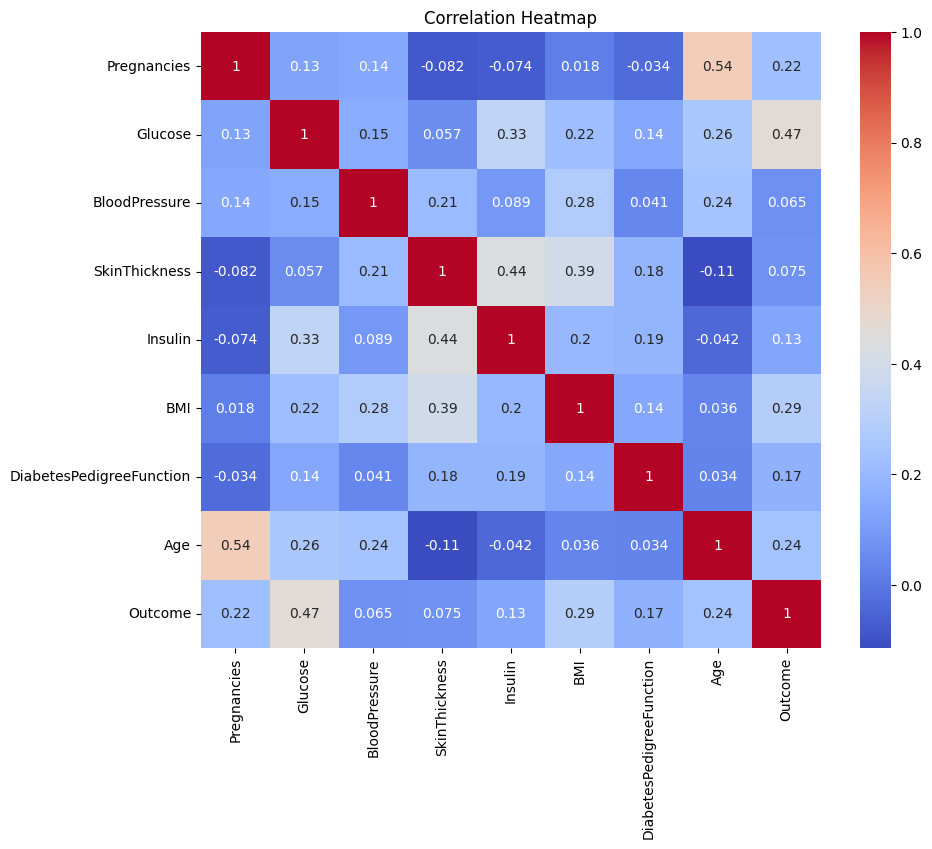

In [261]:
# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Histograms**

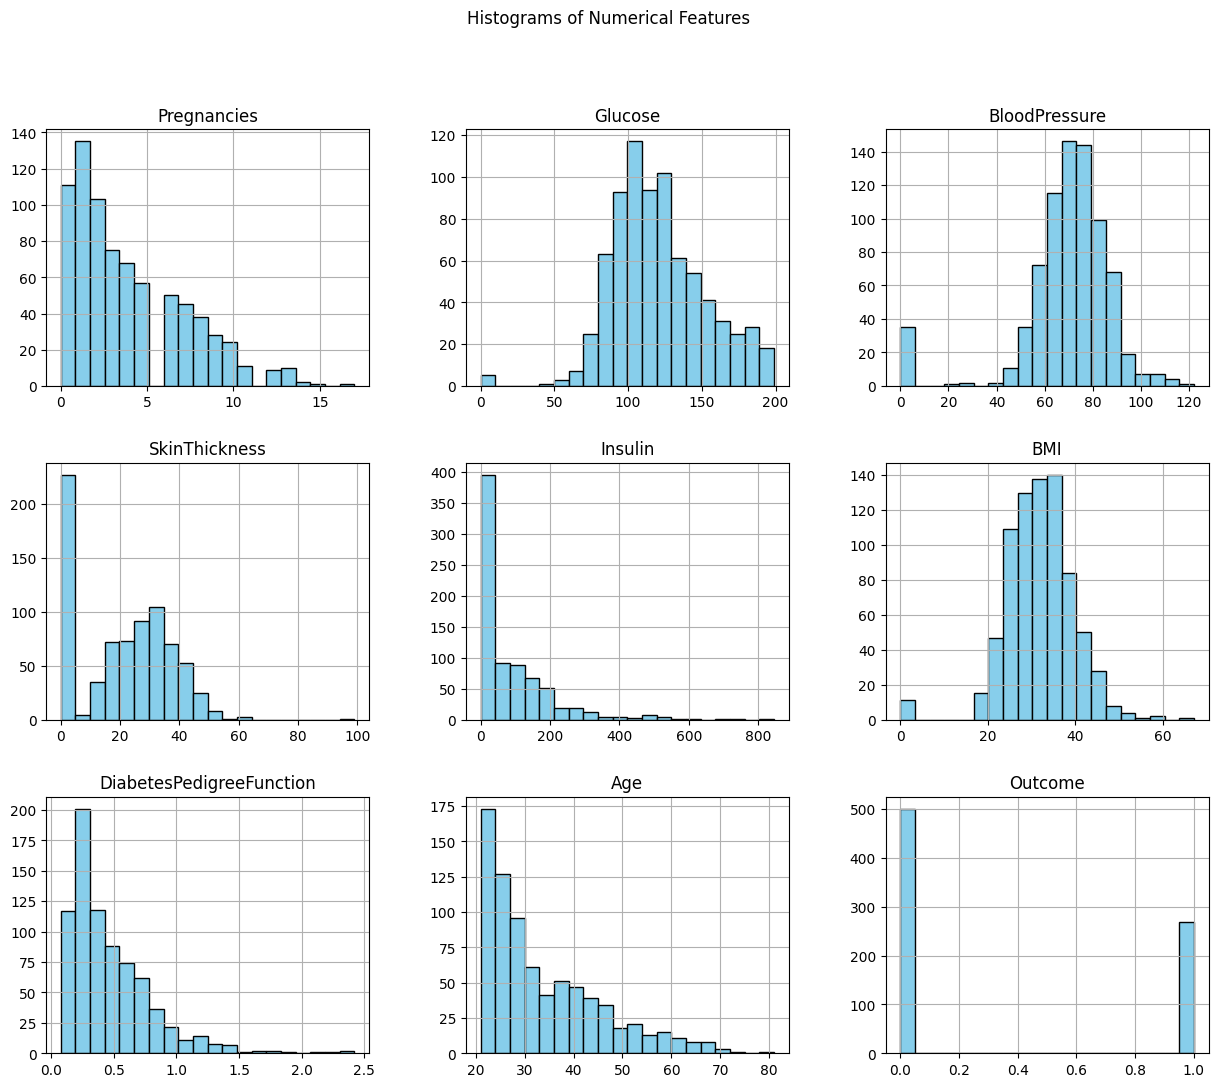

In [262]:
# ===============================
# Step 9: Distribution plots / Histograms
# ===============================
num_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

pdf[num_cols].hist(figsize=(15,12), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numerical Features")
plt.show()

**Boxplots to check outliers**

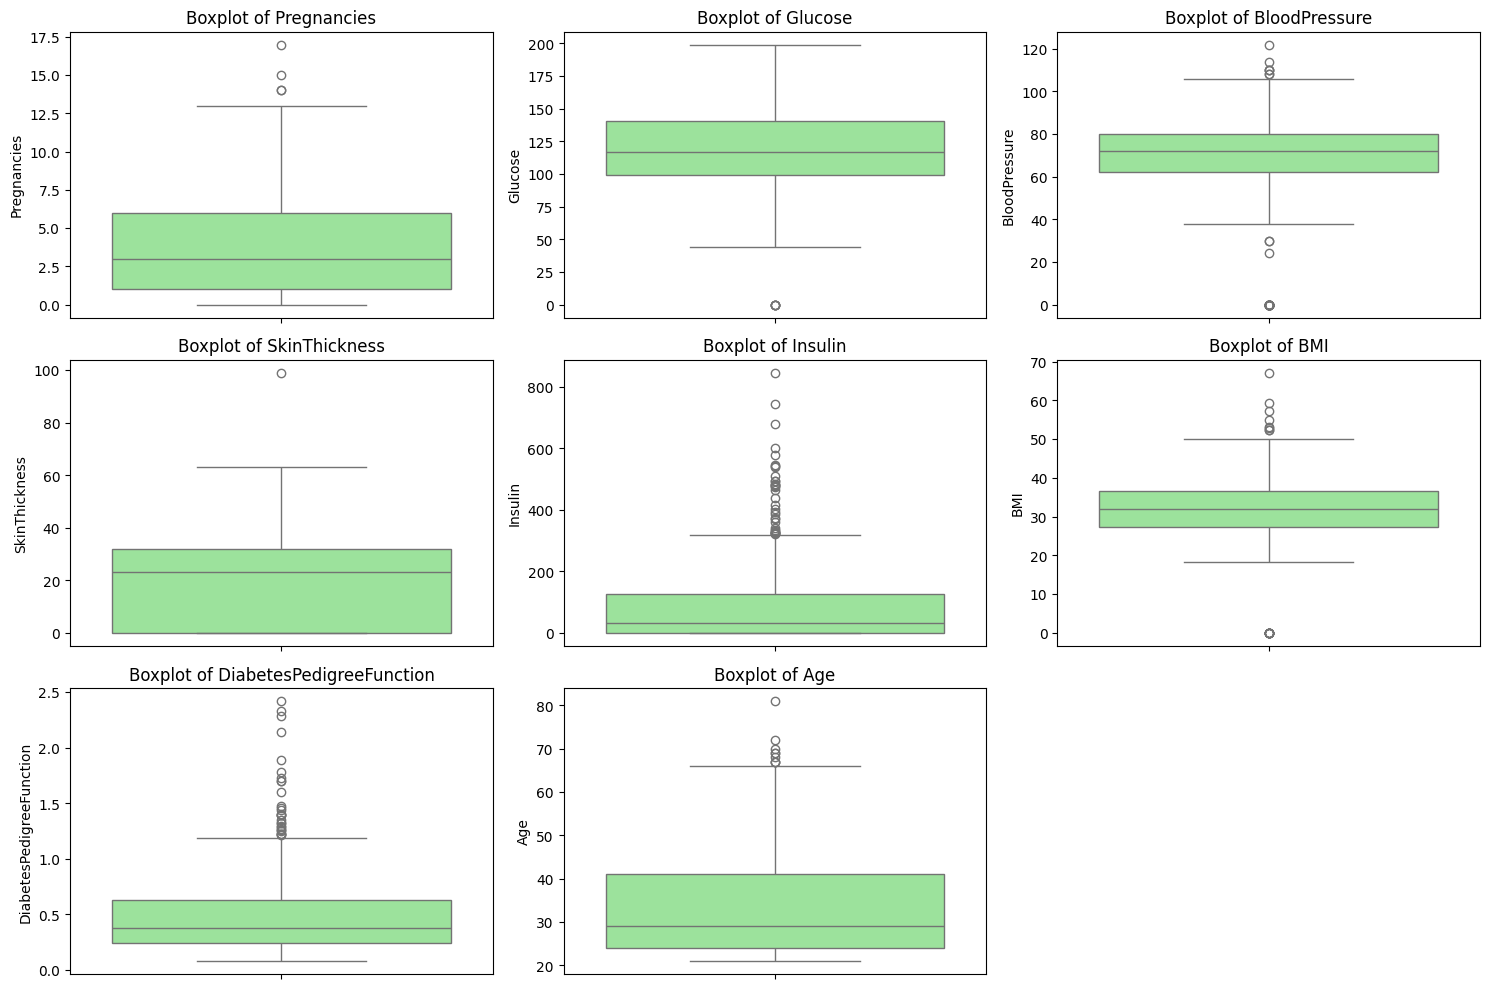

In [263]:
# Step 10: Boxplots to check outliers
# ===============================
plt.figure(figsize=(15,10))
for i, col_name in enumerate(num_cols[:-1], 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=pdf[col_name], color="lightgreen")
    plt.title(f"Boxplot of {col_name}")
plt.tight_layout()
plt.show()

**Class Distribution**

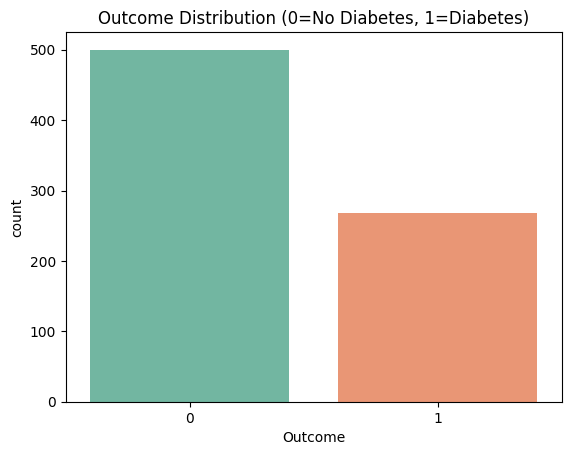

In [264]:
# ===============================
# Step 11: Outcome distribution
# ===============================
sns.countplot(x="Outcome", data=pdf, palette="Set2")
plt.title("Outcome Distribution (0=No Diabetes, 1=Diabetes)")
plt.show()

**Pairplot**

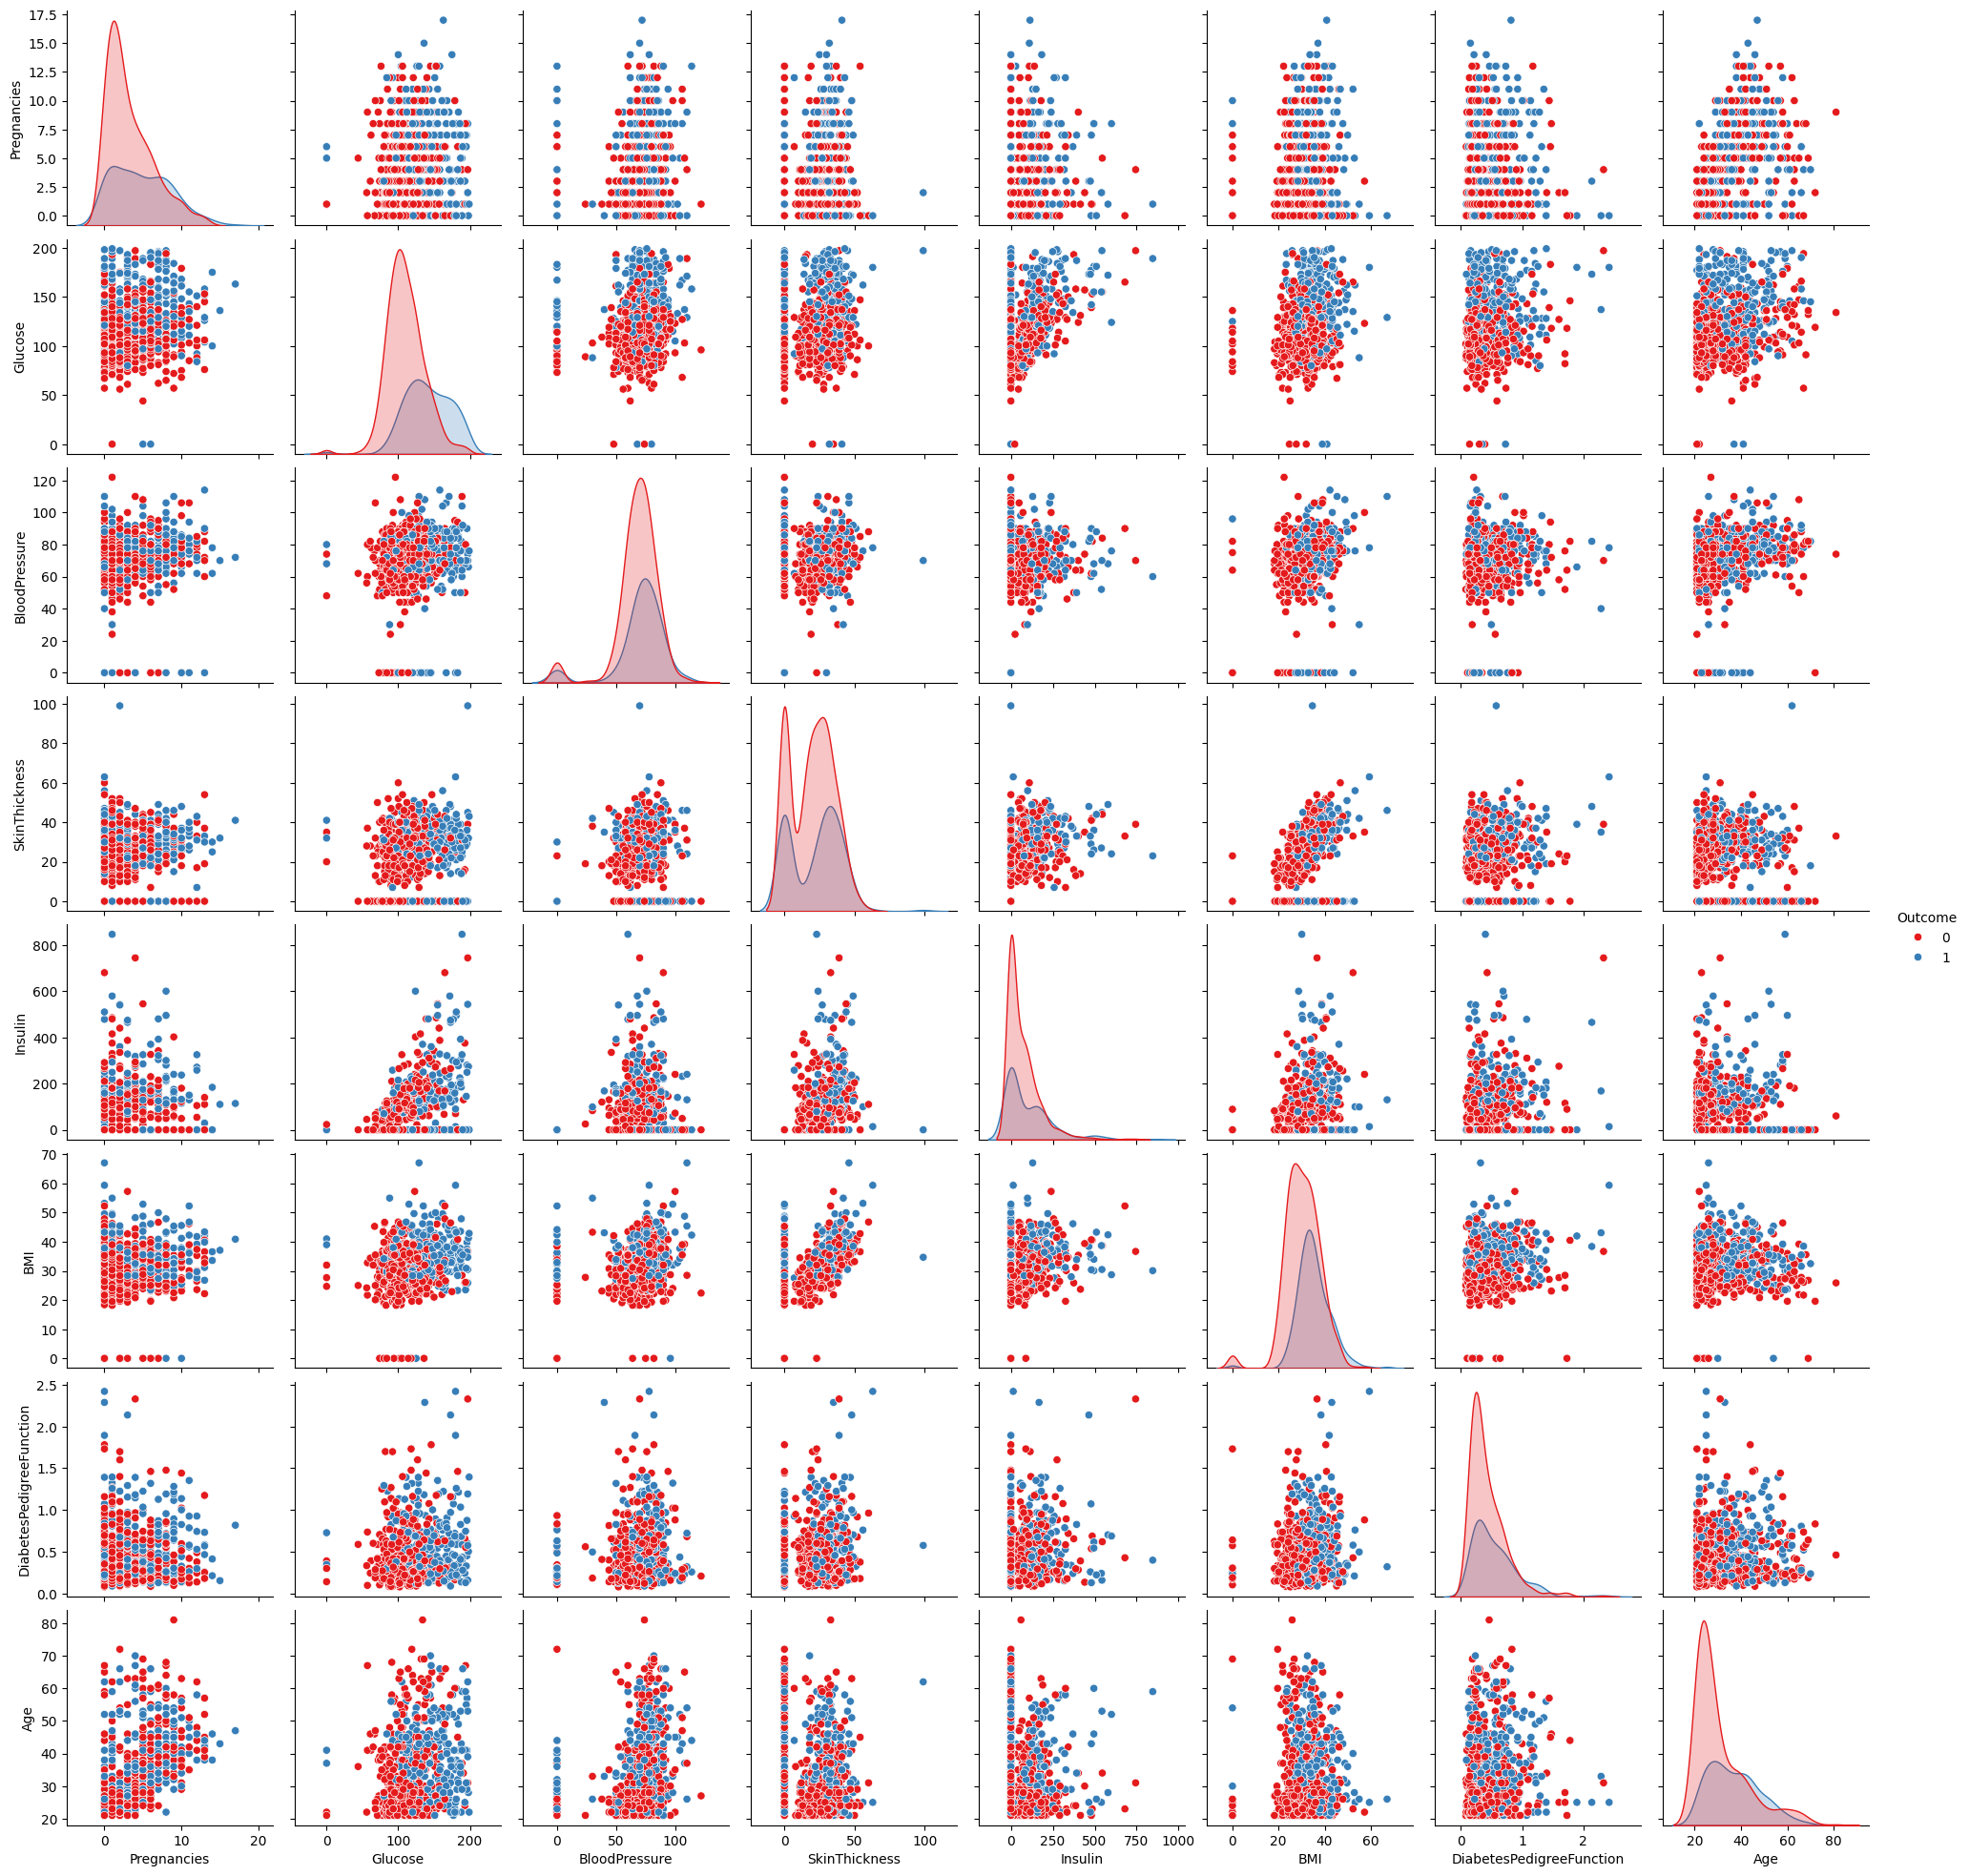

In [265]:
# ===============================
# Step 12: Pairplot / scatter plot for relationships
# ===============================
sns.pairplot(pdf[num_cols], hue="Outcome", palette="Set1")
plt.show()


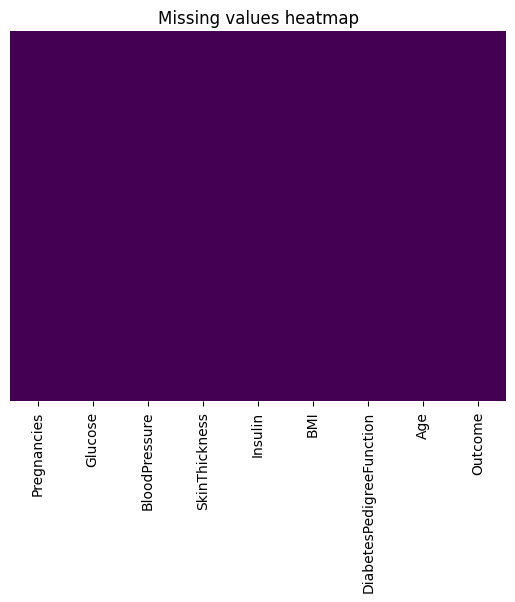

In [266]:
# ===============================
# Step 13: Check null values visually
# ===============================
sns.heatmap(pdf.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing values heatmap")
plt.show()

In [267]:
# ===============================
# Step 14: Correlation with outcome
# ===============================
outcome_corr = pdf.corr()['Outcome'].sort_values(ascending=False)
print("Correlation with Outcome:")
print(outcome_corr)

Correlation with Outcome:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [268]:
# Assuming 'df' is your original DataFrame
df = df.withColumnRenamed("Outcome", "label")
df.show(5)


+-----------+-------+-------------+-------------+-------+----+------------------------+---+-----+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin| BMI|DiabetesPedigreeFunction|Age|label|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-----+
|          6|    148|           72|           35|      0|33.6|                   0.627| 50|    1|
|          1|     85|           66|           29|      0|26.6|                   0.351| 31|    0|
|          8|    183|           64|            0|      0|23.3|                   0.672| 32|    1|
|          1|     89|           66|           23|     94|28.1|                   0.167| 21|    0|
|         10|    115|            0|            0|      0|35.3|                   0.134| 29|    0|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-----+
only showing top 5 rows


**Feature Engineering**

In [269]:

# Exclude the target column 'label' from features
feature_cols = [col for col in df.columns if col != 'label']

# Create a feature vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df = assembler.transform(df)

# Select only 'features' and 'label' for ML
final_df = df.select("features", "label")
final_df.show(5)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[6.0,148.0,72.0,3...|    1|
|[1.0,85.0,66.0,29...|    0|
|[8.0,183.0,64.0,0...|    1|
|[1.0,89.0,66.0,23...|    0|
|[10.0,115.0,0.0,0...|    0|
+--------------------+-----+
only showing top 5 rows


**Split Data into Train and Test**

In [270]:
train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)


**Train Logistic Regression Model**

In [271]:
lr = LogisticRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(train_df)


**Evaluation Metrics**

In [272]:
# Make predictions
predictions = lr_model.transform(test_df)
predictions.select("features", "label", "prediction", "probability").show(5)

+--------------------+-----+----------+--------------------+
|            features|label|prediction|         probability|
+--------------------+-----+----------+--------------------+
|(8,[0,1,6,7],[3.0...|    0|       0.0|[0.98833236743708...|
|(8,[1,5,6,7],[73....|    0|       0.0|[0.95096044539577...|
|(8,[1,5,6,7],[117...|    0|       1.0|[0.39566869681780...|
|(8,[1,5,6,7],[145...|    1|       1.0|[0.15655015430073...|
|[0.0,78.0,88.0,29...|    0|       0.0|[0.93504843720512...|
+--------------------+-----+----------+--------------------+
only showing top 5 rows


In [273]:
evaluator = BinaryClassificationEvaluator(labelCol="label")
accuracy = evaluator.evaluate(predictions)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.8840048840048842


In [274]:
precision_eval = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="weightedPrecision"
)
recall_eval = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="weightedRecall"
)
f1_eval = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="f1"
)

print("Precision:", precision_eval.evaluate(predictions))
print("Recall:", recall_eval.evaluate(predictions))
print("F1-score:", f1_eval.evaluate(predictions))


Precision: 0.8169007144616901
Recall: 0.8211382113821138
F1-score: 0.8167694607980562


**Confusion Matrix**

In [275]:
# Convert predictions to RDD
prediction_and_labels = predictions.select("prediction", "label").rdd.map(lambda x: (float(x[0]), float(x[1])))

# Initialize MulticlassMetrics for confusion matrix and other metrics
metrics = MulticlassMetrics(prediction_and_labels)
# Initialize BinaryClassificationMetrics
binary_metrics = BinaryClassificationMetrics(score_and_labels)


TP: 25.0, TN: 76.0, FP: 8.0, FN: 14.0


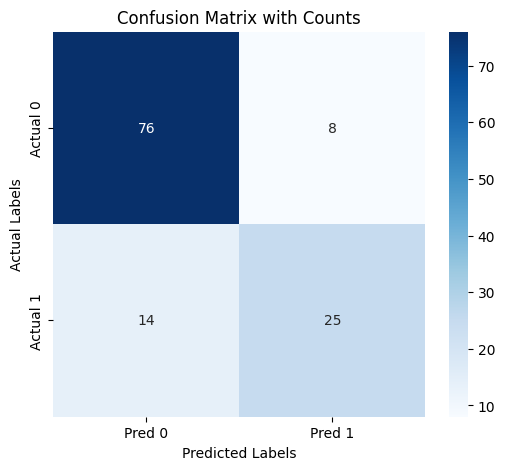

In [276]:
# Confusion matrix
conf_matrix = metrics.confusionMatrix().toArray()
TP = conf_matrix[1][1]
TN = conf_matrix[0][0]
FP = conf_matrix[0][1]
FN = conf_matrix[1][0]

print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=['Pred 0','Pred 1'], yticklabels=['Actual 0','Actual 1'])
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix with Counts")
plt.show()


**ROC-AUC**

In [277]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
roc_auc_test = evaluator.evaluate(predictions)
print(f"Test Data ROC-AUC: {roc_auc_test}")


Test Data ROC-AUC: 0.8840048840048842


In [278]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

binary_evaluator = BinaryClassificationEvaluator(
    labelCol="label", 
    rawPredictionCol="rawPrediction", 
    metricName="areaUnderROC"
)

auc = binary_evaluator.evaluate(predictions)
print("AUC:", auc)


AUC: 0.8840048840048842


ROC-AUC: 0.8303136546859231


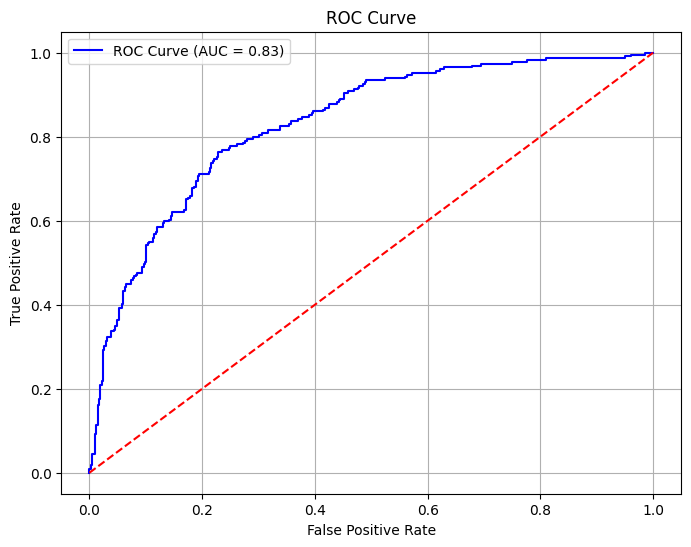

In [279]:
# Get training summary (works for LogisticRegression)
trainingSummary = lr_model.summary

# ROC-AUC
roc_auc = trainingSummary.areaUnderROC
print(f"ROC-AUC: {roc_auc}")

# ROC Curve points
roc_df = trainingSummary.roc.toPandas()  # Returns dataframe with FPR, TPR
fpr = roc_df['FPR']
tpr = roc_df['TPR']

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

**Feature Importance**

In [280]:
# feature_cols = list of feature column names used in VectorAssembler
print("Feature Columns:")
print(feature_cols)


Feature Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [281]:
# Coefficients from logistic regression model
coefficients = lr_model.coefficients.toArray()

# Combine feature names with coefficients
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value of importance
feature_importance_sorted = sorted(feature_importance, key=lambda x: abs(x[1]), reverse=True)

# Display feature importance
print("Feature Importance (sorted by absolute value):")
for feature, coef in feature_importance_sorted:
    print(f"{feature}: {coef}")


Feature Importance (sorted by absolute value):
DiabetesPedigreeFunction: 1.0021736059510866
Pregnancies: 0.11549375799850661
BMI: 0.08638966664743919
Glucose: 0.031458642260825224
Age: 0.016619954326392263
BloodPressure: -0.014116865887079198
Insulin: -0.0006537793876605479
SkinThickness: 0.0006328967734117958


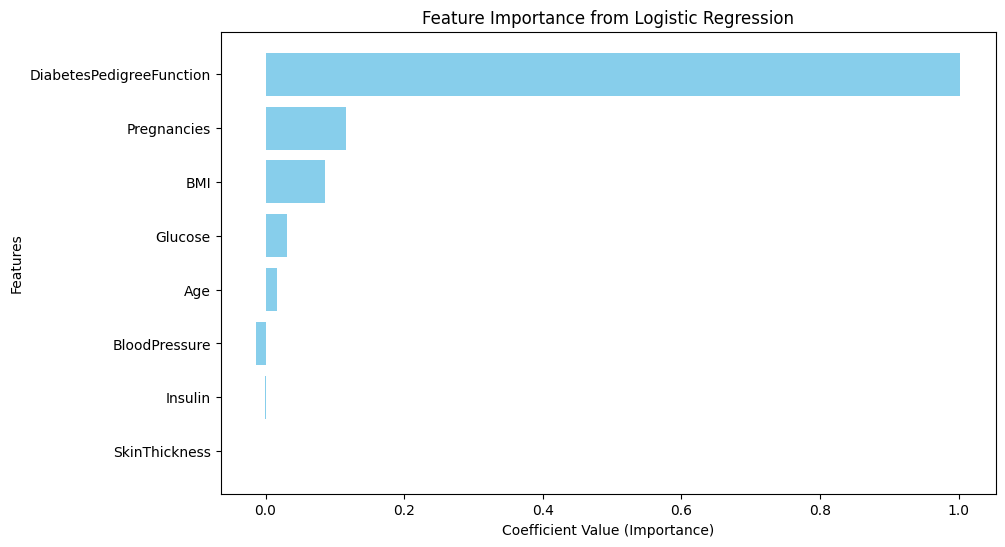

In [282]:
import matplotlib.pyplot as plt

features = [x[0] for x in feature_importance_sorted]
importance = [x[1] for x in feature_importance_sorted]

plt.figure(figsize=(10,6))
plt.barh(features, importance, color='skyblue')
plt.xlabel("Coefficient Value (Importance)")
plt.ylabel("Features")
plt.title("Feature Importance from Logistic Regression")
plt.gca().invert_yaxis()  # Highest importance on top
plt.show()


In [283]:
from pyspark.ml.classification import LogisticRegression

# Assuming lr_model is your trained LogisticRegression model
local_model_path = "./diabetes_lr_model"

# Save model
lr_model.write().overwrite().save(local_model_path)



In [284]:
import os
print(os.listdir("./diabetes_lr_model"))


['metadata', 'data']


In [285]:
!pip install flask


In [ ]:
from flask import Flask, request, jsonify
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegressionModel
from pyspark.sql.types import DoubleType
from datetime import datetime
import sqlite3
import os

# ---------------------------
# CONFIGURATIONS
# ---------------------------
MODEL_DIR = "models/lr_v1"
MODEL_VERSION = "v1.0"
DB_PATH = "predictions.db"

# ---------------------------
# INIT FLASK APP
# ---------------------------
app = Flask(__name__)

# ---------------------------
# INIT SPARK SESSION
# ---------------------------
spark = SparkSession.builder.appName("DiabetesAPI").getOrCreate()

# ---------------------------
# LOAD MODEL
# ---------------------------
try:
    lr_model = LogisticRegressionModel.load(MODEL_DIR)
    print("Model loaded successfully!")
except Exception as e:
    print("MODEL LOAD ERROR:", str(e))
    lr_model = None

# ---------------------------
# FEATURES
# ---------------------------
feature_cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

# ---------------------------
# DB SETUP (ONLY RUNS ONCE)
# ---------------------------
def create_db():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute(
        """
        CREATE TABLE IF NOT EXISTS predictions (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            timestamp TEXT,
            model_version TEXT,
            input_data TEXT,
            prediction INTEGER,
            probability REAL
        )
        """
    )
    conn.commit()
    conn.close()

create_db()

# ---------------------------
# HOME ROUTE
# ---------------------------
@app.route('/', methods=['GET'])
def home():
    return jsonify({
        "message": "Diabetes prediction API is running!",
        "model_version": MODEL_VERSION
    })

# ---------------------------
# PREDICTION ROUTE
# ---------------------------
@app.route('/predict', methods=['POST'])
def predict():

    # Check model loaded
    if lr_model is None:
        return jsonify({"error": "Model not loaded"}), 500

    try:
        data = request.json

        # Validate required fields
        for col in feature_cols:
            if col not in data:
                return jsonify({"error": f"Missing feature: {col}"}), 400

        # Convert to Spark DataFrame
        input_df = spark.createDataFrame([data])

        # Cast columns to double
        for col in feature_cols:
            input_df = input_df.withColumn(col, input_df[col].cast(DoubleType()))

        # Feature Vector
        assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
        input_df = assembler.transform(input_df)

        # Predict
        pred_df = lr_model.transform(input_df)
        pred_row = pred_df.select("prediction", "probability").first()

        prediction = int(pred_row["prediction"])
        probability = float(pred_row["probability"][1])  # prob of class 1 (diabetic)

        # Save to SQLite DB
        conn = sqlite3.connect(DB_PATH)
        cursor = conn.cursor()
        cursor.execute(
            "INSERT INTO predictions (timestamp, model_version, input_data, prediction, probability) VALUES (?, ?, ?, ?, ?)",
            (
                datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                MODEL_VERSION,
                str(data),
                prediction,
                probability
            )
        )
        conn.commit()
        conn.close()

        # Response
        return jsonify({
            "model_version": MODEL_VERSION,
            "prediction": prediction,
            "probability": probability
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500


# ---------------------------
# START FLASK
# ---------------------------
if __name__ == "__main__":
    port = int(os.environ.get("PORT", 5000))
    app.run(host="0.0.0.0", port=port)


Model loaded successfully!
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.22.63.120:5000
INFO:werkzeug:Press CTRL+C to quit


In [292]:
data = {
    "Pregnancies": 2,
    "Glucose": 120,
    "BloodPressure": 70,
    "SkinThickness": 20,
    "Insulin": 79,
    "BMI": 25.0,
    "DiabetesPedigreeFunction": 0.5,
    "Age": 30
}
input_df = spark.createDataFrame([data])
for col in feature_cols:
    input_df = input_df.withColumn(col, input_df[col].cast(DoubleType()))
input_df = VectorAssembler(inputCols=feature_cols, outputCol="features").transform(input_df)
pred_df = lr_model.transform(input_df)
pred_df.show()


+----+----+-------------+------------------------+-------+-------+-----------+-------------+--------------------+--------------------+--------------------+----------+
| Age| BMI|BloodPressure|DiabetesPedigreeFunction|Glucose|Insulin|Pregnancies|SkinThickness|            features|       rawPrediction|         probability|prediction|
+----+----+-------------+------------------------+-------+-------+-----------+-------------+--------------------+--------------------+--------------------+----------+
|30.0|25.0|         70.0|                     0.5|  120.0|   79.0|        2.0|         20.0|[2.0,120.0,70.0,2...|[1.70410990444485...|[0.84607075009888...|       0.0|
+----+----+-------------+------------------------+-------+-------+-----------+-------------+--------------------+--------------------+--------------------+----------+

